In [28]:
import pandas as pd
import pm4py as pm
import datetime as dt

#### Создаем отдельный датасет для кейсов

In [29]:
data_buf = pd.read_csv('final_data.csv', sep =',', encoding='utf-8')
data_final = data_buf.drop(['case:concept:name', 'concept:name', 'time:timestamp', 'hour', 'month', 'year', 'dayofweek'], axis = 1)
data_final_case = data_final.drop(['Time', 'Time_end', 'Name', 'Stage', 'duration', 'Channel'], axis = 1).drop_duplicates()
data_final

,ID,Time_start_case,Time_end_case,case_duration,Stage,Time,Channel,Name,Type,Hit,Place,Model,Price,Like,Time_end,duration,variant,word,cycle
0,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Регистрация претензии,2023-09-12 04:32:23+00:00,Офис,Денис Прохоров,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-12 09:32:23+00:00,300.0,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
1,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Проверка документов,2023-09-12 09:32:23+00:00,Офис,Ксения Петрова,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-12 21:32:23+00:00,720.0,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
2,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Поиск потерянной документации,2023-09-12 21:32:23+00:00,Офис,Алексей Лопухин,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-12 23:32:23+00:00,120.0,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
3,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Проверка документов,2023-09-12 23:32:23+00:00,Офис,Алексей Лопухин,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-13 11:32:23+00:00,720.0,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
4,П00001,2023-09-12 04:32:23+00:00,2023-09-14 14:32:23+00:00,2.416667,Урегулирование претензии,2023-09-13 11:32:23+00:00,Офис,Сидоров Илья,Личный ущерб,ДТП со скрывшимся виновником,Краснодар,Fiat 500X Trekking AWD,128860.0,3,2023-09-14 07:32:23+00:00,1200.0,"('Регистрация претензии', 'Проверка документов...",ABCBDEFGHI,Возврат
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441545,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Получение права на предъявление претензий от с...,2024-08-09 10:20:58+00:00,Офис,Денис Прохоров,Ответственность перед третьими лицами,Боковое столкновение,Челябинск,Lexus LX 600 AWD,526065.0,4,2024-08-09 11:20:58+00:00,60.0,"('Регистрация претензии', 'Проверка документов...",ABDENFGHI,no
441546,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Ремонт автомобиля,2024-08-09 11:20:58+00:00,Офис,Геннадий Кривцов,Ответственность перед третьими лицами,Боковое столкновение,Челябинск,Lexus LX 600 AWD,526065.0,4,2024-08-09 12:20:58+00:00,60.0,"('Регистрация претензии', 'Проверка документов...",ABDENFGHI,no
441547,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Подготовка итоговой документации,2024-08-09 12:20:58+00:00,Офис,Сергей Петров,Ответственность перед третьими лицами,Боковое столкновение,Челябинск,Lexus LX 600 AWD,526065.0,4,2024-08-09 13:20:58+00:00,60.0,"('Регистрация претензии', 'Проверка документов...",ABDENFGHI,no
441548,П09999,2024-08-08 21:17:58+00:00,2024-08-09 15:20:58+00:00,0.752083,Закрытие страхового случая,2024-08-09 13:20:58+00:00,Офис,Елизавета Нестерова,Ответственность перед третьими лицами,Боковое столкновение,Челябинск,Lexus LX 600 AWD,526065.0,4,2024-08-09 15:20:58+00:00,120.0,"('Регистрация претензии', 'Проверка документов...",ABDENFGHI,no


#### Считаем финансовые потери для зацикленностей

In [30]:
cost = 13.895
long_of_dddd = data_final[data_final['word'] == 'ABJDDDDEFGHI']
long_ddd = long_of_dddd[long_of_dddd['Stage'] == 'Урегулирование претензии']
count_ddd = long_of_dddd['Stage'].count()
sum_of_ddd = count_ddd*33.948837*3/8
#sum_of_ddd = long_ddd['duration'].sum()
#sum_of_ddd = sum_of_ddd*3/4
ddd = sum_of_ddd*cost
#dsa = long_ddd['duration']
ddd

np.float64(3334818.107567992)

In [31]:
long_of_dd = data_final[data_final['cycle'] == 'В себя: разово']
long_dd = long_of_dd[long_of_dd['Stage'] == 'Урегулирование претензии']
count_dd = long_of_dd['Stage'].count()
sum_of_dd = count_dd*33.948837/4
#sum_of_dd = long_dd['duration'].sum()
#sum_of_dd = sum_of_dd/2
dd = sum_of_dd*cost
dd

np.float64(5948377.726350149)

In [32]:
long_of_bc = data_final[data_final['cycle'] == 'Возврат']
long_of_b = long_of_bc[long_of_bc['Stage'] == 'Проверка документов']
long_of_c = long_of_bc[long_of_bc['Stage'] == 'Поиск потерянной документации']
count_of_b = long_of_b['duration'].count()
count_of_c = long_of_c['duration'].count()
sum_of_b = count_of_b*33.425834
sum_of_c = count_of_c*23.635397
#sum_of_b = long_of_b['duration'].sum()
#sum_of_c = long_of_c['duration'].sum()
sum_of_bc = (sum_of_b/2)+ sum_of_c
#sum_of_bcbc= (sum_of_b/1.5)+ sum_of_c
bc = sum_of_bc*cost/2
bc

np.float64(1382361.5305729075)

In [33]:
long_of_bc = data_final[data_final['cycle'] == 'Пинг-Понг']
long_of_b = long_of_bc[long_of_bc['Stage'] == 'Проверка документов']
long_of_c = long_of_bc[long_of_bc['Stage'] == 'Поиск потерянной документации']
count_of_b = long_of_b['duration'].count()
count_of_c = long_of_c['duration'].count()
sum_of_b = count_of_b*33.425834
sum_of_c = count_of_c*23.635397
#sum_of_b = long_of_b['duration'].sum()
#sum_of_c = long_of_c['duration'].sum()
#sum_of_bc = (sum_of_b/2)+ sum_of_c
sum_of_bcbc= (sum_of_b/1.5)+ sum_of_c
bcbc= sum_of_bcbc*cost/2
bcbc

np.float64(1237663.5212069452)

In [34]:
print(f"Лишние траты:\n 1) В себя: многократно - {ddd}\n 2) В себя: разово - {dd}\n 3) Возврат - {bc}\n 4) Пинг-Понг - {bcbc}\n ИТОГО - {ddd+dd+bc+bcbc}")

Лишние траты:
 1) В себя: многократно - 3334818.107567992
 2) В себя: разово - 5948377.726350149
 3) Возврат - 1382361.5305729075
 4) Пинг-Понг - 1237663.5212069452
 ИТОГО - 11903220.885697994


#### Считаем лишние траты по операциям с высокой длительностью

In [35]:
long_oper1 = data_final[data_final['Stage'] == 'Проверка документов']
oper1_avg = long_oper1['duration'].mean()
oper1 = long_oper1[long_oper1['duration'] > oper1_avg]
oper1['res_dur'] = oper1['duration'] - oper1_avg
res_oper1 = oper1['res_dur'].sum()
res_oper1

/tmp/ipykernel_20425/2425942296.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oper1['res_dur'] = oper1['duration'] - oper1_avg


np.float64(6359520.73205623)

In [36]:
long_oper2 = data_final[data_final['Stage'] == 'Урегулирование претензии']
oper2_avg = long_oper2['duration'].mean()
oper2 = long_oper2[long_oper2['duration'] > oper2_avg]
oper2['res_dur'] = oper2['duration'] - oper2_avg
res_oper2 = oper2['res_dur'].sum()
long_res = (res_oper2 + res_oper1)*cost/2
print(f"Лишние траты по операциям с высокой длительностью: {long_res} рублей")

Лишние траты по операциям с высокой длительностью: 137087854.63233674 рублей


/tmp/ipykernel_20425/2440841405.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  oper2['res_dur'] = oper2['duration'] - oper2_avg


#### Считаем лишние траты по безуспешным кейсам 

In [37]:
lose = data_final[(data_final['word'] == 'ABDKOHI') | (data_final['word'] == 'ABDOHI')]
lose_sum = lose['duration'].sum()
lose_res = lose_sum*cost
print(f"Лишнее траты из-за кейсов неуспешного типа: {lose_res} рублей ")


Лишнее траты из-за кейсов неуспешного типа: 63912817.605 рублей 


#### Считаем лишние траты по кейсам с нерегулярными операциями

In [38]:
lose = data_final[(data_final['word'] == 'ABDOPEHI') & (data_final['Stage'] == 'Предъявление апелляции по претензии')]
#lose_sum = lose['duration'].sum()
lose_count = lose['duration'].count()
lose_res = lose_count*cost*23.300229
print(f"Лишние траты из-за нерегулярных операций: {lose_res} рублей ")

Лишние траты из-за нерегулярных операций: 973212.58595673 рублей 


#### Альтернативный обсчёт длительности операций (этапов)

In [39]:
sum_of_duration = data_final['duration'].sum()
r = sum_of_duration/1440/15
r

np.float64(4517.984675925925)

In [40]:
print (data_final.head(1))
names = data_final['Name'].unique()
names

       ID            Time_start_case              Time_end_case  \
0  П00001  2023-09-12 04:32:23+00:00  2023-09-14 14:32:23+00:00   

   case_duration                  Stage                       Time Channel  \
0       2.416667  Регистрация претензии  2023-09-12 04:32:23+00:00    Офис   

             Name          Type                           Hit      Place  \
0  Денис Прохоров  Личный ущерб  ДТП со скрывшимся виновником  Краснодар   

                    Model     Price  Like                   Time_end  \
0  Fiat 500X Trekking AWD  128860.0     3  2023-09-12 09:32:23+00:00   

   duration                                            variant        word  \
0     300.0  ('Регистрация претензии', 'Проверка документов...  ABCBDEFGHI   

     cycle  
0  Возврат  


array(['Денис Прохоров', 'Ксения Петрова', 'Алексей Лопухин',
       'Сидоров Илья', 'Геннадий Кривцов', 'Алёна Волкова',
       'Инна Смирнова', 'Анна Егорова', 'Леонид Куликов',
       'Семён Афанасьев', 'Владимир Воробьёв', 'Сергей Петров',
       'Елизавета Нестерова', 'Михаил Трофимов', 'Николай Кабанов'],
      dtype=object)

In [41]:
n = 0
names_data = pd.DataFrame()
for name in names:
    bufer_data = data_final[data_final['Name'] == name]
    bufer = bufer_data.sort_values('Time')
    bufer['Time'] = pd.to_datetime(bufer['Time'])
    bufer['time_difference'] = bufer['Time'].diff().shift(-1)
    bufer['time_diff_minutes'] = bufer['time_difference'].dt.total_seconds() / 60
    if n == 0:
        names_data = bufer
        n = 1
    else:
        names_data = pd.concat([names_data, bufer], ignore_index=True)
names_data

,ID,Time_start_case,Time_end_case,case_duration,Stage,Time,Channel,Name,Type,Hit,...,Model,Price,Like,Time_end,duration,variant,word,cycle,time_difference,time_diff_minutes
0,П034451,2023-02-04 22:25:28+00:00,2023-02-06 05:27:28+00:00,1.293056,Проверка документов,2023-02-04 22:27:28+00:00,Офис,Денис Прохоров,Личный ущерб,Боковое столкновение,...,Kia Seltos SX Turbo AWD,454070.0,5,2023-02-05 10:27:28+00:00,720.0,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no,0 days 00:17:06,17.100000
1,П011836,2023-02-04 22:34:34+00:00,2023-02-05 04:44:34+00:00,0.256944,Утверждение претензии,2023-02-04 22:44:34+00:00,Сайт,Денис Прохоров,Личный ущерб,Переднее столкновение,...,Porsche Panamera GTS,280840.0,4,2023-02-04 23:44:34+00:00,60.0,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no,0 days 02:43:14,163.233333
2,П00455,2023-02-04 22:27:48+00:00,2023-02-06 13:27:48+00:00,1.625000,Проверка документов,2023-02-05 01:27:48+00:00,Сайт,Денис Прохоров,Личный ущерб,Боковое столкновение,...,Nissan Armada Platinum Reserve AWD,441150.0,4,2023-02-05 11:27:48+00:00,600.0,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no,0 days 00:57:32,57.533333
3,П07785,2023-02-05 02:25:20+00:00,2023-02-06 20:25:20+00:00,1.750000,Регистрация претензии,2023-02-05 02:25:20+00:00,Офис,Денис Прохоров,Личный ущерб,Переднее столкновение,...,Kia Telluride SX Prestige AWD,1900770.0,4,2023-02-05 07:25:20+00:00,300.0,"('Регистрация претензии', 'Проверка документов...",ABDKELMHI,no,0 days 00:19:14,19.233333
4,П011836,2023-02-04 22:34:34+00:00,2023-02-05 04:44:34+00:00,0.256944,Закрытие страхового случая,2023-02-05 02:44:34+00:00,Сайт,Денис Прохоров,Личный ущерб,Переднее столкновение,...,Porsche Panamera GTS,280840.0,4,2023-02-05 04:44:34+00:00,120.0,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no,0 days 02:00:00,120.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441545,П025702,2025-02-03 00:13:18+00:00,2025-02-04 00:15:18+00:00,1.001389,Ремонт автомобиля,2025-02-03 19:15:18+00:00,Сайт,Николай Кабанов,Личный ущерб,Боковое столкновение,...,Fiat 124 Spider Abarth,292995.0,4,2025-02-03 21:15:18+00:00,120.0,"('Регистрация претензии', 'Проверка документов...",ABDENFGHI,no,0 days 02:56:36,176.600000
441546,П041995,2025-02-02 10:11:54+00:00,2025-02-04 00:11:54+00:00,1.583333,Закрытие страхового случая,2025-02-03 22:11:54+00:00,Сайт,Николай Кабанов,Ответственность перед третьими лицами,Переднее столкновение,...,Volvo XC60 Recharge T8,1448995.0,1,2025-02-04 00:11:54+00:00,120.0,"('Регистрация претензии', 'Проверка документов...",ABDKOHI,no,0 days 20:03:37,1203.616667
441547,П035887,2025-02-03 15:11:31+00:00,2025-02-04 18:15:31+00:00,1.127778,Обзор произошедшего случая,2025-02-04 18:15:31+00:00,Сайт,Николай Кабанов,Личный ущерб,Боковое столкновение,...,Toyota Tacoma,606900.0,5,2025-02-04 18:15:31+00:00,0.0,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no,0 days 02:26:47,146.783333
441548,П045902,2025-02-03 10:37:18+00:00,2025-02-04 20:42:18+00:00,1.420139,Обзор произошедшего случая,2025-02-04 20:42:18+00:00,Сайт,Николай Кабанов,Личный ущерб,Заднее столкновение,...,Volkswagen ID.4 Pro S,2254965.0,5,2025-02-04 20:42:18+00:00,0.0,"('Регистрация претензии', 'Проверка документов...",ABDKELMHI,no,0 days 02:10:19,130.316667


In [42]:
names_clean_data = names_data.dropna()
names_clean_data = names_clean_data[names_clean_data['duration'] > names_clean_data['time_diff_minutes']]
names_clean_data

,ID,Time_start_case,Time_end_case,case_duration,Stage,Time,Channel,Name,Type,Hit,...,Model,Price,Like,Time_end,duration,variant,word,cycle,time_difference,time_diff_minutes
0,П034451,2023-02-04 22:25:28+00:00,2023-02-06 05:27:28+00:00,1.293056,Проверка документов,2023-02-04 22:27:28+00:00,Офис,Денис Прохоров,Личный ущерб,Боковое столкновение,...,Kia Seltos SX Turbo AWD,454070.0,5,2023-02-05 10:27:28+00:00,720.0,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no,0 days 00:17:06,17.100000
2,П00455,2023-02-04 22:27:48+00:00,2023-02-06 13:27:48+00:00,1.625000,Проверка документов,2023-02-05 01:27:48+00:00,Сайт,Денис Прохоров,Личный ущерб,Боковое столкновение,...,Nissan Armada Platinum Reserve AWD,441150.0,4,2023-02-05 11:27:48+00:00,600.0,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no,0 days 00:57:32,57.533333
3,П07785,2023-02-05 02:25:20+00:00,2023-02-06 20:25:20+00:00,1.750000,Регистрация претензии,2023-02-05 02:25:20+00:00,Офис,Денис Прохоров,Личный ущерб,Переднее столкновение,...,Kia Telluride SX Prestige AWD,1900770.0,4,2023-02-05 07:25:20+00:00,300.0,"('Регистрация претензии', 'Проверка документов...",ABDKELMHI,no,0 days 00:19:14,19.233333
7,П05040,2023-02-05 07:08:15+00:00,2023-02-06 20:13:15+00:00,1.545139,Проверка документов,2023-02-05 07:13:15+00:00,Сайт,Денис Прохоров,Личный ущерб,Столкновение нескольких автомобилей,...,Alfa Romeo 156,1772420.0,4,2023-02-05 14:13:15+00:00,420.0,"('Регистрация претензии', 'Проверка документов...",ABDKELMHI,no,0 days 01:08:56,68.933333
8,П038888,2023-02-05 08:22:11+00:00,2023-02-06 10:25:11+00:00,1.085417,Регистрация претензии,2023-02-05 08:22:11+00:00,Офис,Денис Прохоров,Личный ущерб,Переднее столкновение,...,Toyota Tacoma TRD Pro,536180.0,1,2023-02-05 12:22:11+00:00,240.0,"('Регистрация претензии', 'Проверка документов...",ABJDEFGHI,no,0 days 03:03:01,183.016667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441532,П05878,2025-02-01 23:55:01+00:00,2025-02-02 21:57:01+00:00,0.918056,Регистрация претензии,2025-02-01 23:55:01+00:00,Телефон,Николай Кабанов,Личный ущерб,Столкновение нескольких автомобилей,...,Fiat 500L Trekking,493425.0,5,2025-02-02 03:55:01+00:00,240.0,"('Регистрация претензии', 'Проверка документов...",ABDENFGHI,no,0 days 00:19:37,19.616667
441534,П046491,2025-01-31 21:07:30+00:00,2025-02-02 14:07:30+00:00,1.708333,Ремонт автомобиля,2025-02-02 09:07:30+00:00,Офис,Николай Кабанов,Личный ущерб,Боковое столкновение,...,Mitsubishi Outlander PHEV SEL AWD,501500.0,5,2025-02-02 11:07:30+00:00,120.0,"('Регистрация претензии', 'Проверка документов...",ABDEFGHI,no,0 days 01:58:52,118.866667
441538,П05683,2025-02-02 01:04:33+00:00,2025-02-03 16:08:33+00:00,1.627778,Урегулирование претензии,2025-02-02 20:08:33+00:00,Сайт,Николай Кабанов,Личный ущерб,Опрокидывание автомобиля,...,Lincoln MKT,432565.0,3,2025-02-03 12:08:33+00:00,960.0,"('Регистрация претензии', 'Проверка документов...",ABCBCBDEFGHI,Пинг-Понг,0 days 02:58:51,178.850000
441539,П019832,2025-02-02 17:07:24+00:00,2025-02-05 00:07:24+00:00,2.291667,Проверка документов,2025-02-02 23:07:24+00:00,Сайт,Николай Кабанов,Личный ущерб,Заднее столкновение,...,Jaguar E-PACE R-Dynamic SE,121125.0,1,2025-02-03 09:07:24+00:00,600.0,"('Регистрация претензии', 'Проверка документов...",ABJDDEFGHI,В себя: разово,0 days 07:32:50,452.833333


In [43]:
stage_time = names_clean_data.groupby('Stage')['time_diff_minutes'].mean()
stage_time


Stage
Закрытие страхового случая                                   23.612591
Отклонение претензии                                         23.644951
Отправка платежа                                             23.551203
Подготовка итоговой документации                             23.672653
Поиск потерянной документации                                23.635397
Получение права на предъявление претензий от страхователя    23.800308
Получение страховых резервов                                 23.423696
Предъявление апелляции по претензии                          23.300229
Проверка документов                                          33.425834
Проверка на мошенничество                                    23.916636
Регистрация претензии                                        31.144293
Ремонт автомобиля                                            23.539379
Урегулирование объёма убытков                                23.618899
Урегулирование претензии                                     33.948837


In [44]:
stage_time = names_clean_data.groupby('Stage')['time_diff_minutes'].median()
stage_time

Stage
Закрытие страхового случая                                   17.250000
Отклонение претензии                                         17.050000
Отправка платежа                                             17.116667
Подготовка итоговой документации                             17.133333
Поиск потерянной документации                                17.116667
Получение права на предъявление претензий от страхователя    17.133333
Получение страховых резервов                                 17.000000
Предъявление апелляции по претензии                          16.900000
Проверка документов                                          18.883333
Проверка на мошенничество                                    17.433333
Регистрация претензии                                        18.550000
Ремонт автомобиля                                            17.083333
Урегулирование объёма убытков                                17.141667
Урегулирование претензии                                     18.716667


In [45]:
stage_time = names_clean_data.groupby('Stage')['time_diff_minutes'].std()
stage_time

Stage
Закрытие страхового случая                                   21.973726
Отклонение претензии                                         22.197714
Отправка платежа                                             21.858594
Подготовка итоговой документации                             22.079037
Поиск потерянной документации                                22.061863
Получение права на предъявление претензий от страхователя    22.277362
Получение страховых резервов                                 21.446933
Предъявление апелляции по претензии                          21.810255
Проверка документов                                          45.126651
Проверка на мошенничество                                    22.381546
Регистрация претензии                                        37.341487
Ремонт автомобиля                                            21.940665
Урегулирование объёма убытков                                21.900788
Урегулирование претензии                                     50.056184


In [46]:
bottle_neck = names_clean_data[['Stage', 'duration', 'time_diff_minutes']]
bottle_neck = bottle_neck[(bottle_neck['Stage'] == 'Проверка документов') | (bottle_neck['Stage'] == 'Урегулирование претензии')]
bottle_neck

,Stage,duration,time_diff_minutes
0,Проверка документов,720.0,17.100000
2,Проверка документов,600.0,57.533333
7,Проверка документов,420.0,68.933333
9,Урегулирование претензии,720.0,8.700000
10,Проверка документов,420.0,31.966667
...,...,...,...
441522,Урегулирование претензии,1020.0,90.583333
441527,Урегулирование претензии,720.0,69.700000
441528,Урегулирование претензии,1260.0,71.816667
441538,Урегулирование претензии,960.0,178.850000


/tmp/ipykernel_20425/3609505292.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box1 = plt.boxplot(duration_data, labels=stages, patch_artist=True)
/tmp/ipykernel_20425/3609505292.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box2 = plt.boxplot(time_diff_data, labels=stages, patch_artist=True)


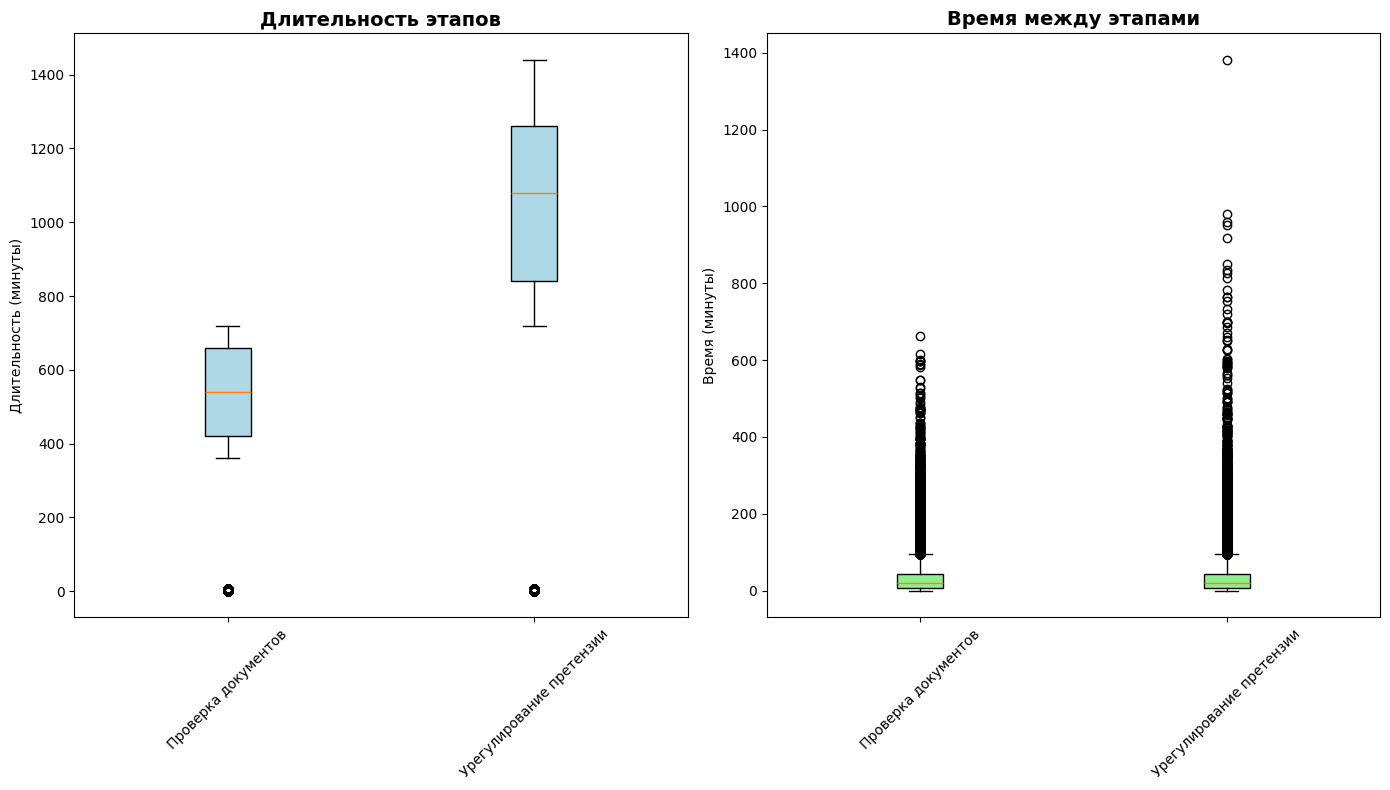

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 8))
stages = bottle_neck['Stage'].unique()
duration_data = [bottle_neck[bottle_neck['Stage'] == stage]['duration'] for stage in stages]
time_diff_data = [bottle_neck[bottle_neck['Stage'] == stage]['time_diff_minutes'] for stage in stages]

plt.subplot(1, 2, 1)
box1 = plt.boxplot(duration_data, labels=stages, patch_artist=True)
plt.title('Длительность этапов', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Длительность (минуты)')

plt.subplot(1, 2, 2)
box2 = plt.boxplot(time_diff_data, labels=stages, patch_artist=True)
plt.title('Время между этапами', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Время (минуты)')

colors = ['lightblue', 'lightgreen']
for box, color in zip([box1, box2], colors):
    for patch in box['boxes']:
        patch.set_facecolor(color)

plt.tight_layout()
plt.show()


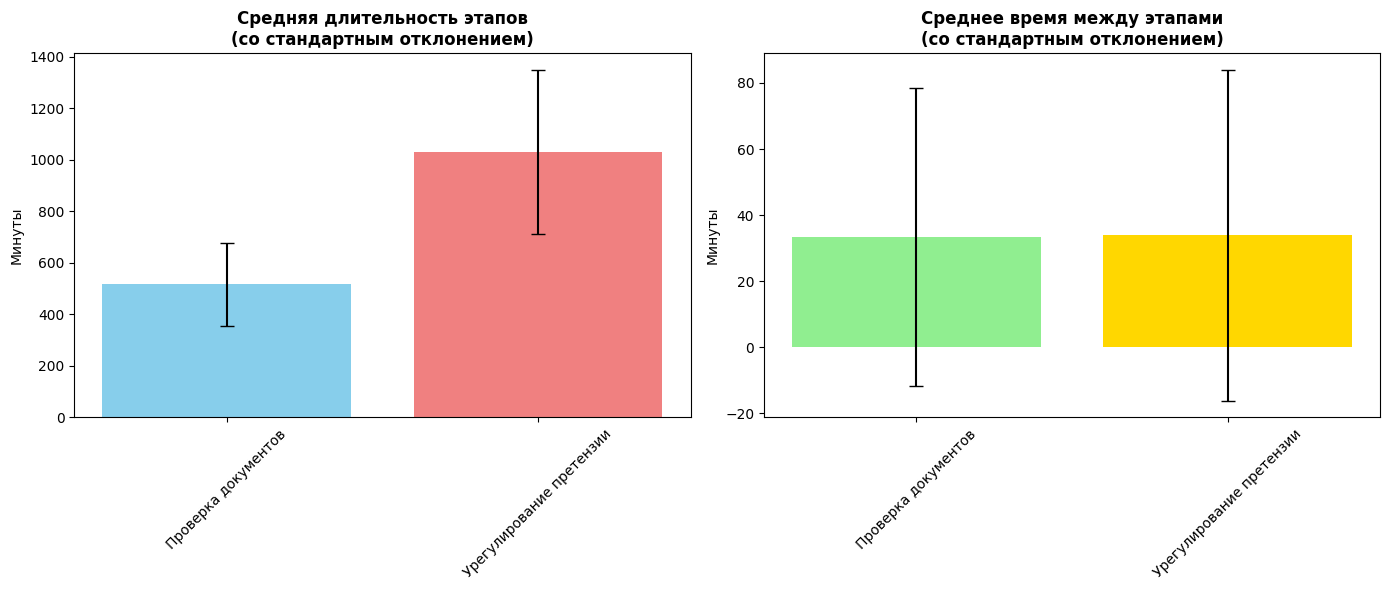

In [48]:
import matplotlib.pyplot as plt

stats = bottle_neck.groupby('Stage').agg({
    'duration': ['mean', 'std'],
    'time_diff_minutes': ['mean', 'std']
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

means_duration = stats[('duration', 'mean')]
stds_duration = stats[('duration', 'std')]

ax1.bar(means_duration.index, means_duration.values, 
        yerr=stds_duration.values, capsize=5, color=['skyblue', 'lightcoral'])
ax1.set_title('Средняя длительность этапов\n(со стандартным отклонением)', fontweight='bold')
ax1.set_ylabel('Минуты')
ax1.tick_params(axis='x', rotation=45)

means_time_diff = stats[('time_diff_minutes', 'mean')]
stds_time_diff = stats[('time_diff_minutes', 'std')]

ax2.bar(means_time_diff.index, means_time_diff.values,
        yerr=stds_time_diff.values, capsize=5, color=['lightgreen', 'gold'])
ax2.set_title('Среднее время между этапами\n(со стандартным отклонением)', fontweight='bold')
ax2.set_ylabel('Минуты')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

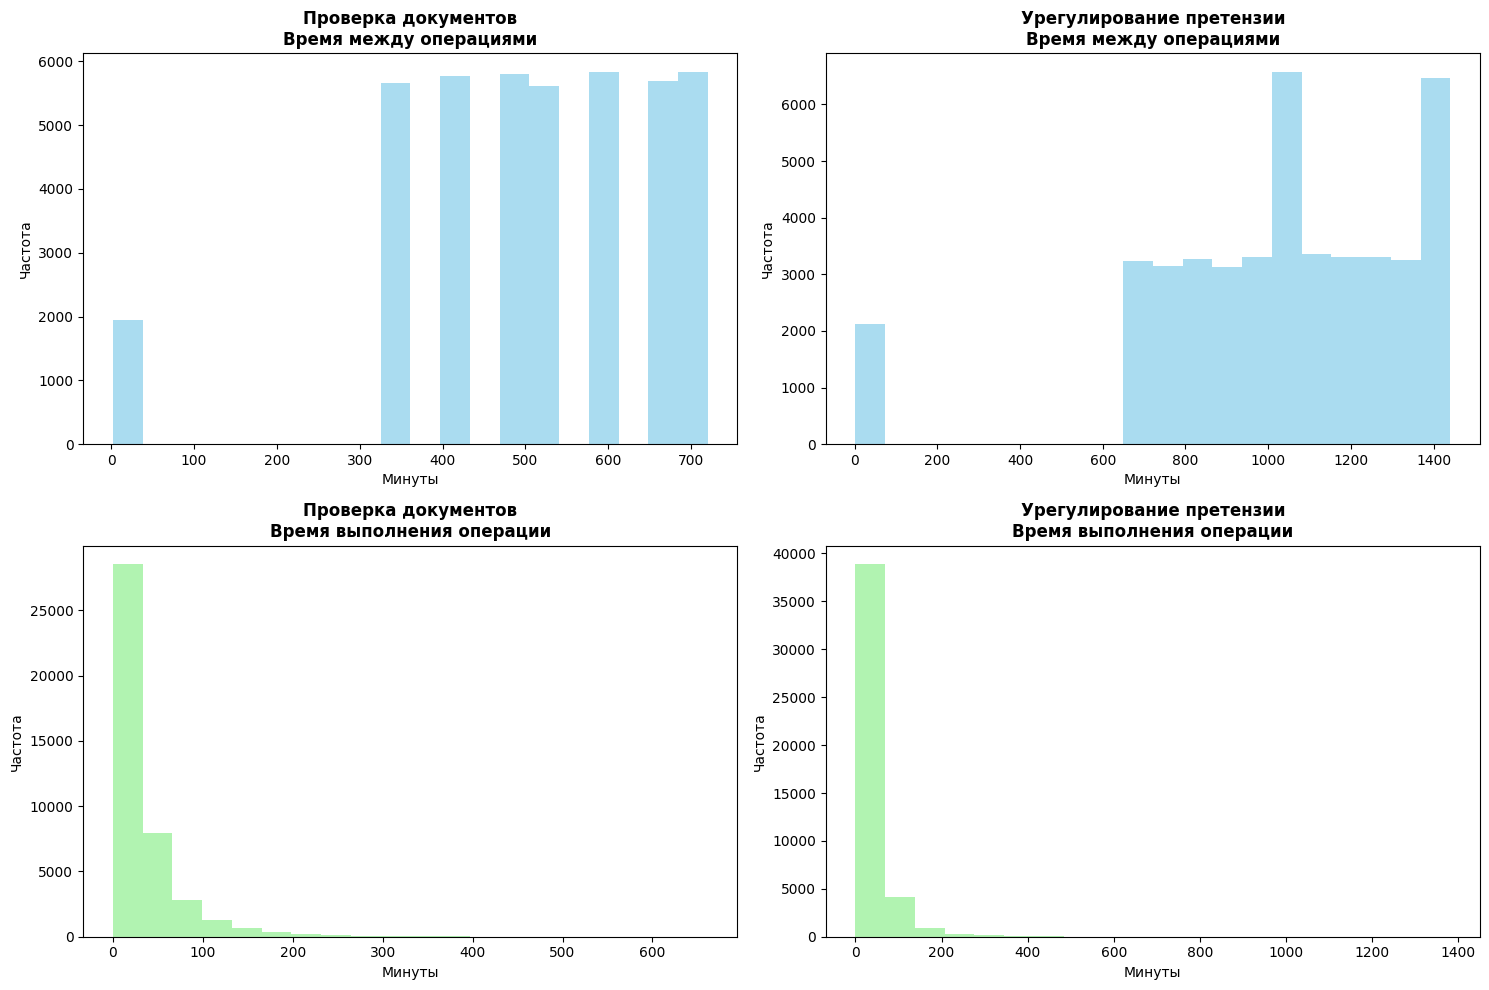

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for i, stage in enumerate(stages):
    stage_data = bottle_neck[bottle_neck['Stage'] == stage]
    
    axes[0, i].hist(stage_data['duration'], bins=20, alpha=0.7, color='skyblue')
    axes[0, i].set_title(f'{stage}\nВремя между операциями', fontweight='bold')
    axes[0, i].set_xlabel('Минуты')
    axes[0, i].set_ylabel('Частота')
    
    axes[1, i].hist(stage_data['time_diff_minutes'], bins=20, alpha=0.7, color='lightgreen')
    axes[1, i].set_title(f'{stage}\nВремя выполнения операции', fontweight='bold')
    axes[1, i].set_xlabel('Минуты')
    axes[1, i].set_ylabel('Частота')

plt.tight_layout()
plt.show()

In [50]:
real_time_names = names_clean_data.groupby('Name')['time_diff_minutes'].sum().reset_index()
rtn = real_time_names.sort_values('time_diff_minutes')
rtn

,Name,time_diff_minutes
11,Николай Кабанов,173154.750000
10,Михаил Трофимов,415432.250000
3,Владимир Воробьёв,425889.750000
8,Ксения Петрова,469301.033333
1,Алёна Волкова,511868.983333
6,Елизавета Нестерова,531559.700000
4,Геннадий Кривцов,605200.400000
7,Инна Смирнова,641586.850000
12,Семён Афанасьев,642857.083333
0,Алексей Лопухин,678852.466667


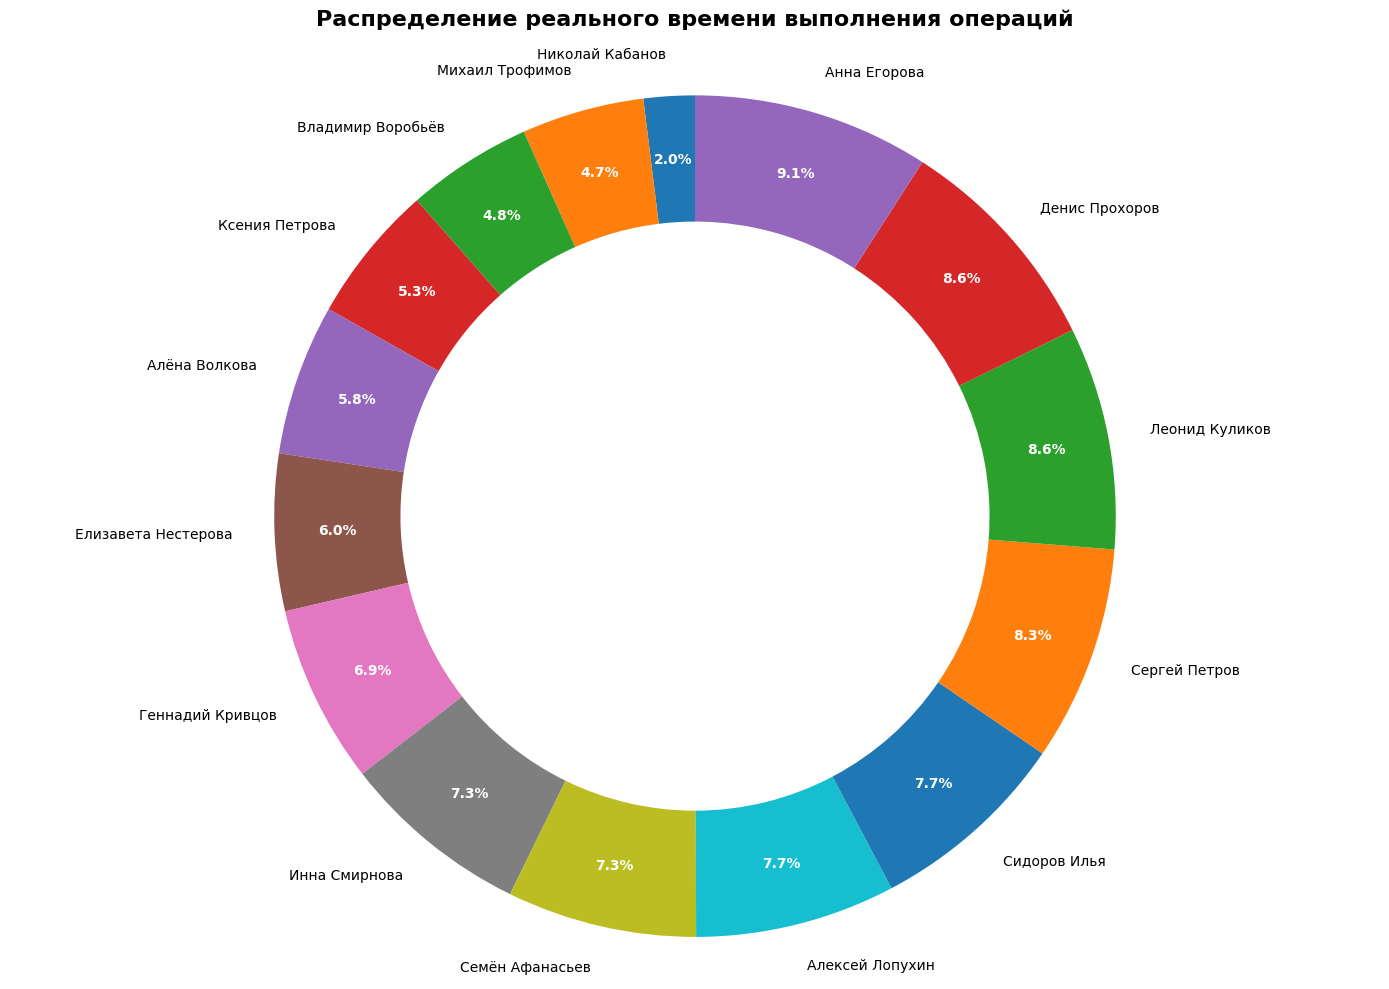

In [51]:
plt.figure(figsize=(14, 10))
wedges, texts, autotexts = plt.pie(rtn['time_diff_minutes'], labels=rtn['Name'], 
                                   autopct='%1.1f%%', startangle=90,
                                   wedgeprops=dict(width=0.3), pctdistance=0.85)

plt.title('Распределение реального времени выполнения операций', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

In [52]:
count_oper = data_final.groupby('Name')['Stage'].count().reset_index().sort_values('Stage')
count_oper

,Name,Stage
11,Николай Кабанов,3641
10,Михаил Трофимов,12273
3,Владимир Воробьёв,13118
8,Ксения Петрова,14957
1,Алёна Волкова,17977
6,Елизавета Нестерова,19367
4,Геннадий Кривцов,25333
12,Семён Афанасьев,29545
7,Инна Смирнова,29978
0,Алексей Лопухин,33401


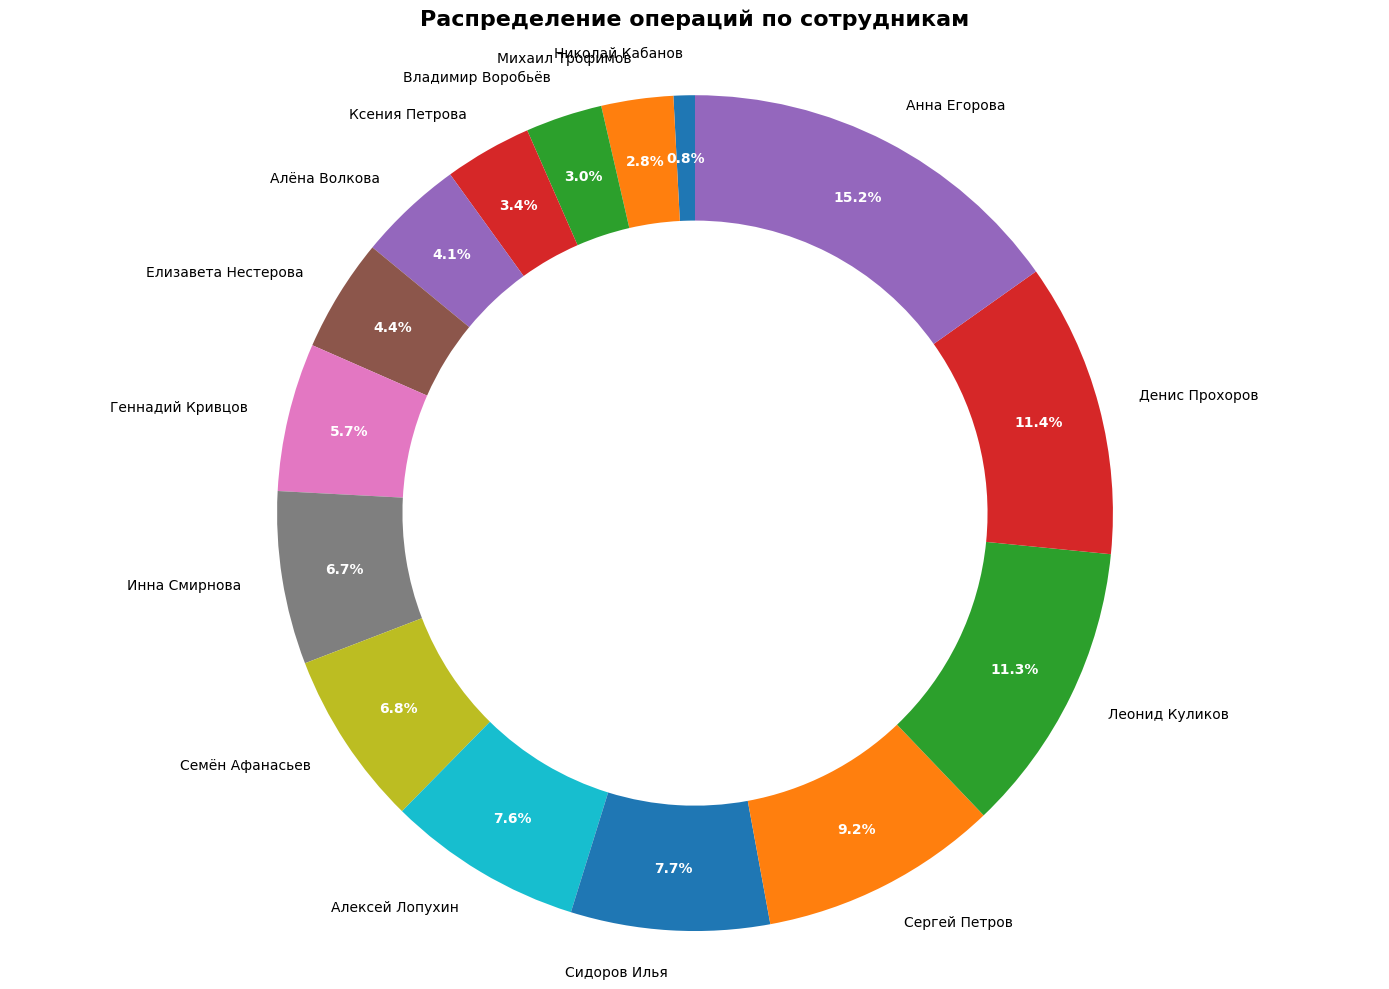

In [53]:
plt.figure(figsize=(14, 10))
wedges, texts, autotexts = plt.pie(count_oper['Stage'], labels=rtn['Name'], 
                                   autopct='%1.1f%%', startangle=90,
                                   wedgeprops=dict(width=0.3), pctdistance=0.85)

plt.title('Распределение операций по сотрудникам', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.show()

In [54]:
o = data_final_case['Like'].mean()
o

np.float64(3.4216509935235497)

In [55]:
ncd = names_clean_data[['ID', 'Stage', 'Name', 'duration', 'time_diff_minutes','Like', 'word', 'cycle']]
ncd.to_csv('times_csv', index=False)
ncd.head(30)

,ID,Stage,Name,duration,time_diff_minutes,Like,word,cycle
0,П034451,Проверка документов,Денис Прохоров,720.0,17.100000,5,ABDEFGHI,no
2,П00455,Проверка документов,Денис Прохоров,600.0,57.533333,4,ABDEFGHI,no
3,П07785,Регистрация претензии,Денис Прохоров,300.0,19.233333,4,ABDKELMHI,no
7,П05040,Проверка документов,Денис Прохоров,420.0,68.933333,4,ABDKELMHI,no
8,П038888,Регистрация претензии,Денис Прохоров,240.0,183.016667,1,ABJDEFGHI,no
9,П017291,Урегулирование претензии,Денис Прохоров,720.0,8.700000,1,ABDOHI,no
10,П045084,Проверка документов,Денис Прохоров,420.0,31.966667,4,ABDKELMHI,no
11,П020177,Проверка документов,Денис Прохоров,540.0,19.316667,2,ABCBDEFGHI,Возврат
12,П038888,Проверка на мошенничество,Денис Прохоров,120.0,24.550000,1,ABJDEFGHI,no
13,П021097,Проверка документов,Денис Прохоров,720.0,95.450000,5,ABDENFGHI,no
